In [1]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("tundesta18/sales-forecast-dataset")
df=dataset['train'].to_pandas()

Repo card metadata block was not found. Setting CardData to empty.


### Which Product Type Generated the most Sales?


In [2]:
df.columns=df.columns.str.lower()
product_pivot=df.pivot_table(index='product_type',values='product_store_sales_total',aggfunc='sum')
product_pivot=product_pivot.sort_values(by='product_store_sales_total',ascending=False).head(8)
product_pivot

,product_store_sales_total
product_type,
Fruits and Vegetables,3403395.81
Snack Foods,3070486.51
Frozen Foods,2212372.41
Dairy,2096103.10
Household,2040758.53
Baking Goods,1961077.80
Canned,1847637.54
Health and Hygiene,1724568.03


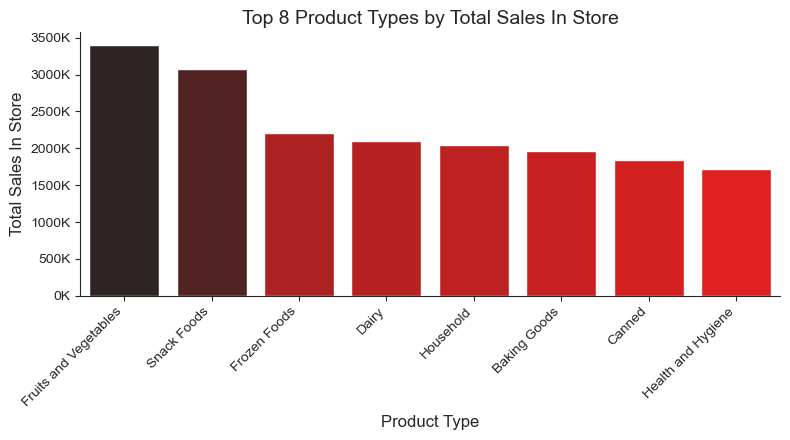

In [41]:
# Plotting the Top 8 Product Type by Total Sales
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
fig,ax=plt.subplots(1,1,figsize=(8,4.5))
sns.set_style('ticks')
sns.barplot(data=product_pivot,x=product_pivot.index,
y='product_store_sales_total'
,ax=ax,hue='product_store_sales_total'
,palette='dark:r_r',legend=False)
sns.despine()
plt.xlabel('Product Type',fontsize=12)
plt.ylabel('Total Sales In Store',fontsize=12)
plt.title('Top 8 Product Types by Total Sales In Store',fontsize=14)
plt.xticks(rotation=45,ha='right',fontsize=10)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

### Analyze the Store Performance

In [17]:
# Which Stores are driving the business.
store_performance=df.groupby('store_size')['product_store_sales_total'].agg(['mean','sum','count'])
store_performance=store_performance.sort_values(by='sum',ascending=False)
store_performance

,mean,sum,count
store_size,,,
Medium,3299.312111,15427583.43,4676
High,3923.778802,6223113.18,1586
Small,1762.942465,2030909.72,1152


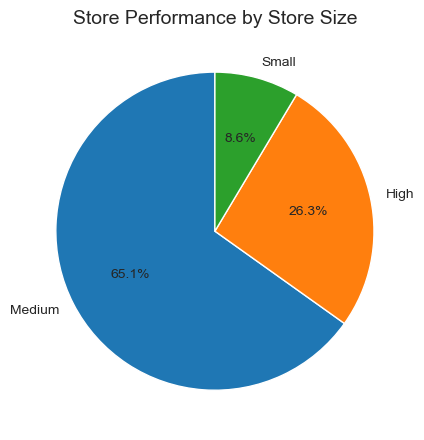

In [39]:
# Plotting the store performance by store size.
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
fig,ax=plt.subplots(1,1,figsize=(8,4.5))
sns.set_style('whitegrid')
plt.pie(store_performance['sum'],labels=store_performance.index,autopct='%1.1f%%',startangle=90)
sns.despine()
plt.title('Store Performance by Store Size',fontsize=14)
plt.tight_layout()
plt.show()

### Store Type Analysis

In [52]:
# Which store Types gets the highest Sales.
store_type_sales=df.groupby('store_type')['product_store_sales_total'].agg(['mean','sum','count'])
store_type_sales=store_type_sales.sort_values(by='sum',ascending=False)
store_type_sales

,mean,sum,count
store_type,,,
Supermarket Type2,3299.312111,15427583.43,4676
Supermarket Type1,3923.778802,6223113.18,1586
Food Mart,1762.942465,2030909.72,1152


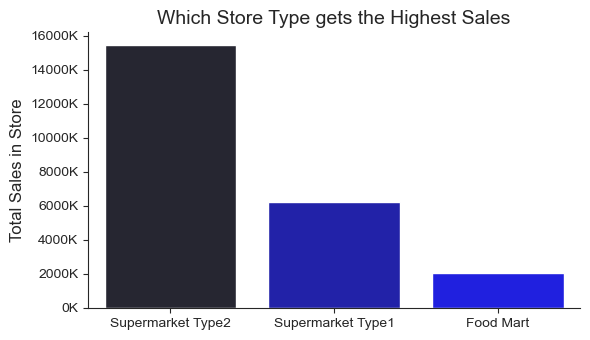

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
fig,ax=plt.subplots(1,1,figsize=(6,3.5))
sns.set_style('ticks')
sns.barplot(data=store_type_sales,x=store_type_sales.index,y='sum',ax=ax,hue='sum',palette='dark:b_r',legend=False)
sns.despine()
plt.title('Which Store Type gets the Highest Sales',fontsize=14)
plt.xlabel('')
plt.ylabel('Total Sales in Store',fontsize=12)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x,pos: f'{x/1000:.0f}K')
)
plt.tight_layout()
plt.show()